In [ ]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np

from keras.applications.xception import Xception, preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tqdm.notebook import tqdm

## Flickr - 8 k Data set

In [ ]:

dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

## Preparing the data

In [ ]:

def load_doc(filename):
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions ={}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [ caption ]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

def cleaning_text(captions):
    table = str.maketrans('','',string.punctuation)
    for img,caps in captions.items():
        for i,img_caption in enumerate(caps):

            img_caption.replace("-"," ")
            desc = img_caption.split()

            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if(len(word)>1)]
            desc = [word for word in desc if(word.isalpha())]

            img_caption = ' '.join(desc)
            captions[img][i]= img_caption
    return captions

def text_vocabulary(descriptions):
    vocab = set()

    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]

    return vocab

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc )
    data = "\n".join(lines)
    file = open(filename,"w")
    file.write(data)
    file.close()


In [ ]:

filename = dataset_text + "/" + "Flickr8k.token.txt"
descriptions = all_img_captions(filename)
print("Length of descriptions =" ,len(descriptions))

clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary = ", len(vocabulary))

#saving each description to file 
save_descriptions(clean_descriptions, "descriptions.txt")

Length of descriptions = 8092
Length of vocabulary =  8763


## Feature Extraction using Xception

In [ ]:
def extract_features(directory):
        model = Xception( include_top=False, pooling='avg' )
        features = {}
        for img in tqdm(os.listdir(directory)):
            filename = directory + "/" + img
            image = Image.open(filename)
            image = image.resize((299,299))
            image = np.expand_dims(image, axis=0)
            image = image/127.5
            image = image - 1.0

            feature = model.predict(image)
            features[img] = feature
        return features


In [ ]:

#2048 feature vector
features = extract_features(dataset_images)
dump(features, open("features.p","wb"))

In [ ]:
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos):
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)
    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))
    features = {k: all_features[k] for k in photos}
    return features

filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)


In [ ]:

from keras.preprocessing.text import Tokenizer

def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc



def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [ ]:

tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size

7577

In [ ]:
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)

max_length = max_length(descriptions)
max_length


32

### Data Generator

In [ ]:
def data_generator(descriptions, features, tokenizer, max_length):
    while 1:
        for key, description_list in descriptions.items():
            feature = features[key][0]
            input_image, input_sequence, output_word = create_sequences(tokenizer, max_length, description_list, feature)
            yield [[input_image, input_sequence], output_word]

def create_sequences(tokenizer, max_length, desc_list, feature):
    X1, X2, y = list(), list(), list()
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

[a, b], c = next(data_generator(train_descriptions, train_features, tokenizer, max_length))
a.shape, b.shape, c.shape


((47, 2048), (47, 32), (47, 7577))

### CNN-RNN model



In [ ]:
from keras.utils import plot_model

def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')

    print(model.summary())
    plot_model(model, to_file='model.png', show_shapes=True)

    return model


### Training

In [ ]:
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

model = define_model(vocab_size, max_length)
epochs = 10
steps = len(train_descriptions)
os.mkdir("models")
for i in range(epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
    model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)
    model.save("models/model_" + str(i) + ".h5")


### Testing 

2025-05-05 21:01:04.845382: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-05-05 21:01:04.845417: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-05-05 21:01:04.845432: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-05-05 21:01:04.845467: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-05 21:01:04.845485: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-05-05 21:01:06.720840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


2025-05-05 21:01:08.086119: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-05 21:01:08.302993: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.





start end


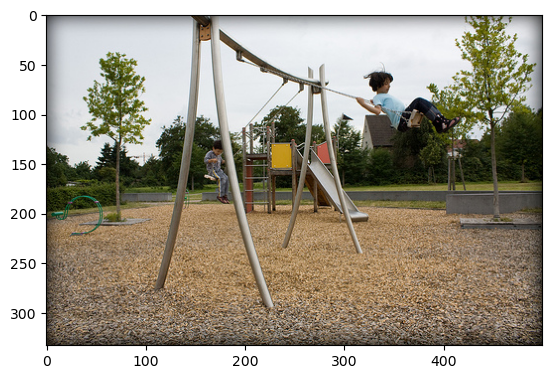

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse

def extract_features(filename, model):
    try:
        image = Image.open(filename)
    except:
        print("ERROR: Couldn't open image! Make sure the image path and extension is correct")
    image = image.resize((299, 299))
    image = np.array(image)
    if image.shape[2] == 4:
        image = image[..., :3]
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text

img_path = 'dataset/Flicker8k_Dataset/3717809376_f97611ab84.jpg'
max_length = 32
tokenizer = load(open("tokenizer.p", "rb"))
model = load_model('models/model_8.h5')
xception_model = Xception(include_top=False, pooling="avg")

photo = extract_features(img_path, xception_model)
img = Image.open(img_path)

description = generate_desc(model, tokenizer, photo, max_length)
print("\n\n")
print(description)
plt.imshow(img)


### Average Scores

In [ ]:
import os
import numpy as np
from keras.models import load_model
from keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import Xception
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tqdm import tqdm
from pickle import load
import nltk

nltk.download('wordnet')

# Feature extractor
def extract_features(filename, model):
    image = load_img(filename, target_size=(299, 299))
    image = img_to_array(image)
    if image.shape[-1] == 4:
        image = image[..., :3]
    image = np.expand_dims(image, axis=0)
    image = image / 127.5 - 1.0
    feature = model.predict(image, verbose=0)
    return feature

# Word ID to word
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Caption generation
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text.replace('start', '').replace('end', '').strip()

# Load descriptions
def load_ground_truth(file_path):
    gt = {}
    with open(file_path, 'r') as file:
        for line in file:
            img, caption = line.split('\t')
            img = img.strip()
            caption = caption.strip()
            if img not in gt:
                gt[img] = []
            gt[img].append(caption)
    return gt

# Load test image IDs
def load_image_ids(filename):
    with open(filename, 'r') as file:
        return [line.strip() for line in file.readlines()]

# ===================== EVALUATION =====================

tokenizer = load(open("tokenizer.p", "rb"))
model = load_model("models/model_8.h5")
xception_model = Xception(include_top=False, pooling='avg')
max_length = 32

# Paths
image_dir = "dataset/Flicker8k_Dataset/"
description_path = "descriptions.txt"
test_ids_path = "dataset/Flickr8k_text/Flickr_8k.testImages.txt"

# Load data
ground_truth = load_ground_truth(description_path)
test_image_ids = load_image_ids(test_ids_path)

# Evaluate all test images
smooth = SmoothingFunction().method4
bleu1s, bleu2s, bleu3s, bleu4s, meteors = [], [], [], [], []

for img_id in tqdm(test_image_ids, desc="Evaluating"):
    image_path = os.path.join(image_dir, img_id)
    photo = extract_features(image_path, xception_model)
    if photo is None:
        continue

    generated = generate_desc(model, tokenizer, photo, max_length).split()
    references = [caption.split() for caption in ground_truth[img_id]]

    bleu1s.append(sentence_bleu(references, generated, weights=(1.0, 0, 0, 0), smoothing_function=smooth))
    bleu2s.append(sentence_bleu(references, generated, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth))
    bleu3s.append(sentence_bleu(references, generated, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth))
    bleu4s.append(sentence_bleu(references, generated, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))
    meteors.append(meteor_score(references, generated))

# Average scores
print("\n✅ Average Scores on Test Set:")
print(f"BLEU-1: {np.mean(bleu1s):.4f}")
print(f"BLEU-2: {np.mean(bleu2s):.4f}")
print(f"BLEU-3: {np.mean(bleu3s):.4f}")
print(f"BLEU-4: {np.mean(bleu4s):.4f}")
print(f"METEOR: {np.mean(meteors):.4f}")
